In [1]:
import regex as re
log_file = "../logs/log_default_20250929_214135.txt"
# 2025-09-29 21:42:18,050 - Step 155: loss 3.5868 tokens/sec 68,629 Tflops/sec 6.53
# 2025-09-29 21:42:20,274 - Step 164: loss 3.7020 tokens/sec 66,288 Tflops/sec 6.31

# write a regex to extract the training loss from lines
loss_pattern = r"Step (\d+): loss (\d+\.\d+) tokens/sec (\d+,\d+) Tflops/sec (\d+\.\d+)"
#2025-09-29 21:43:49,139 - Validation loss. step 410: 3.0947
val_loss_pattern = r"Validation loss. step (\d+): (\d+\.\d+)"
all_steps = []
all_losses = []

all_val_steps = []
all_val_losses = []
with open(log_file, "r") as f:
    for line in f:
        match = re.search(loss_pattern, line)
        if match:
            step = int(match.group(1))
            loss = float(match.group(2))
            tokens_per_sec = int(match.group(3).replace(",", ""))
            tflops_per_sec = float(match.group(4))
            print(f"Step: {step}, Loss: {loss}, Tokens/sec: {tokens_per_sec}, Tflops/sec: {tflops_per_sec}")
            all_steps.append(step)
            all_losses.append(loss)
        match = re.search(val_loss_pattern, line)
        if match:
            step = int(match.group(1))
            val_loss = float(match.group(2))
            print(f"Validation Step: {step}, Validation Loss: {val_loss}")
            all_val_steps.append(step)
            all_val_losses.append(val_loss)

Step: 7, Loss: 8.392, Tokens/sec: 63119, Tflops/sec: 6.01
Step: 16, Loss: 6.3137, Tokens/sec: 69790, Tflops/sec: 6.64
Step: 25, Loss: 5.2129, Tokens/sec: 69716, Tflops/sec: 6.64
Step: 34, Loss: 4.5895, Tokens/sec: 69591, Tflops/sec: 6.63
Step: 43, Loss: 4.4578, Tokens/sec: 69387, Tflops/sec: 6.61
Step: 51, Loss: 4.2102, Tokens/sec: 65318, Tflops/sec: 6.22
Step: 59, Loss: 4.0745, Tokens/sec: 65151, Tflops/sec: 6.2
Step: 68, Loss: 4.0741, Tokens/sec: 68094, Tflops/sec: 6.48
Step: 77, Loss: 3.905, Tokens/sec: 28790, Tflops/sec: 2.74
Step: 86, Loss: 4.2038, Tokens/sec: 67051, Tflops/sec: 6.38
Step: 95, Loss: 3.8099, Tokens/sec: 67041, Tflops/sec: 6.38
Step: 104, Loss: 3.8508, Tokens/sec: 69599, Tflops/sec: 6.63
Step: 113, Loss: 3.8507, Tokens/sec: 69525, Tflops/sec: 6.62
Step: 121, Loss: 3.7377, Tokens/sec: 64683, Tflops/sec: 6.16
Step: 129, Loss: 3.7495, Tokens/sec: 63201, Tflops/sec: 6.02
Step: 137, Loss: 3.7054, Tokens/sec: 58682, Tflops/sec: 5.59
Step: 146, Loss: 3.7642, Tokens/sec: 65

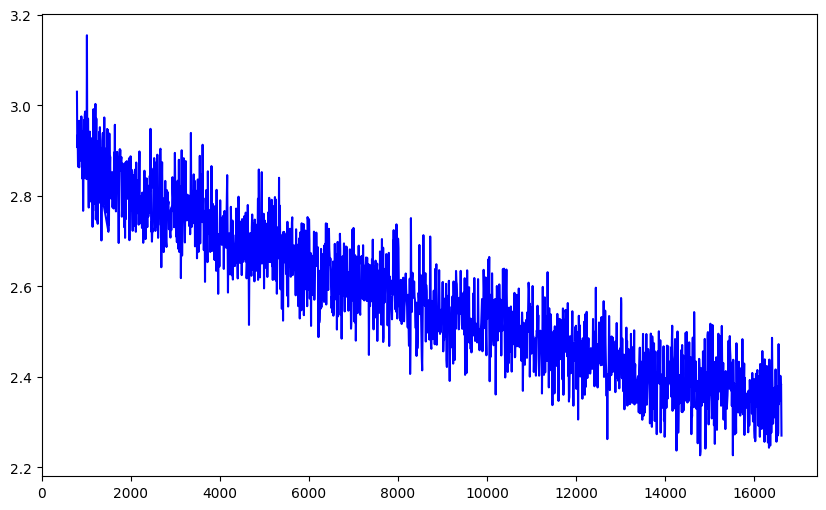

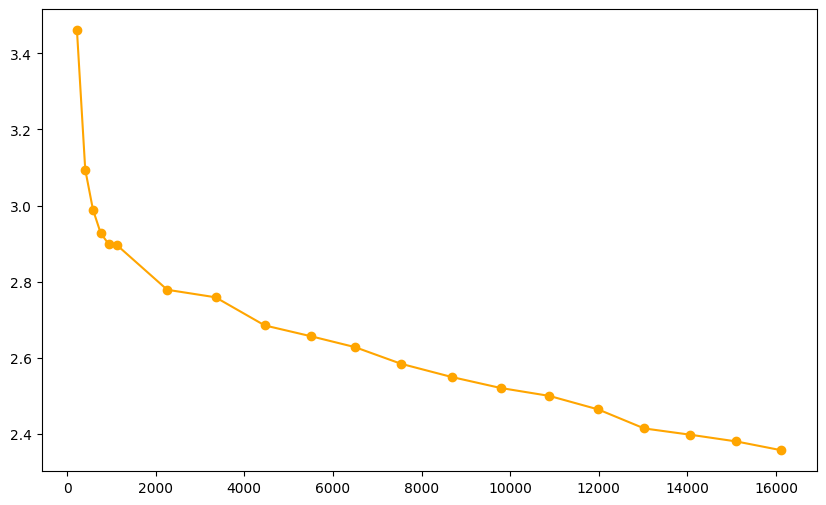

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
start_index = 100
plt.plot(all_steps[start_index:], all_losses[start_index:], label="Training Loss", color="blue")

# new plot for validation loss
if all_val_steps:
    plt.figure(figsize=(10, 6))
    plt.plot(all_val_steps, all_val_losses, label="Validation Loss", color="orange", marker='o')